In [25]:
import numpy as np 
import pandas as pd           
import matplotlib as plt                   
import seaborn as sns             
import tensorflow as tf 
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

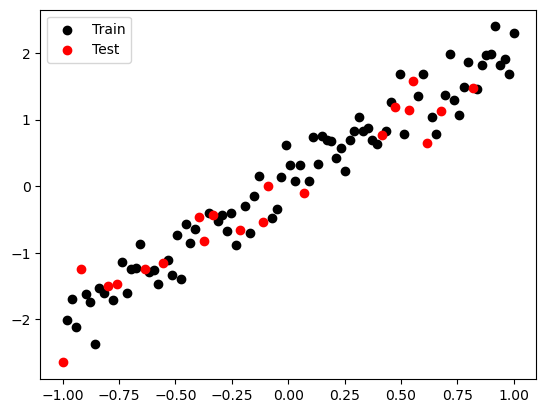

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Generate synthetic linear data with noise
X = np.linspace(-1, 1, 100)
y = 2 * X + np.random.normal(0, 0.3, 100) # y = 2x + noise

# 2. Reshape for ANN input
X = X.reshape(-1, 1)

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Visualize the data
plt.scatter(X_train, y_train, color='black', label='Train')
plt.scatter(X_test, y_test, color='red', label='Test')
plt.legend()
plt.show()

In [ ]:
model=Sequential()
X_train.shape

(80, 1)

In [46]:
model.add(Dense(10,activation='relu',input_dim=1))
model.add(Dropout(0.5))
model.add(Dense(8,activation='relu',input_dim=1))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
from tensorflow.keras.optimizers import Adam 
adam=Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse'])
history=model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

In [42]:
#evaluate the model
train_mse= model.evaluate(X_train,y_train,verbose=0)
test_mse=model.evaluate(X_test,y_test,verbose=0)
print('Train: {}, test: {}'.format(train_mse,test_mse))

Train: [0.8541067242622375, 0.8541067242622375], test: [0.925083339214325, 0.925083339214325]


In [43]:
y_pred=model.predict(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


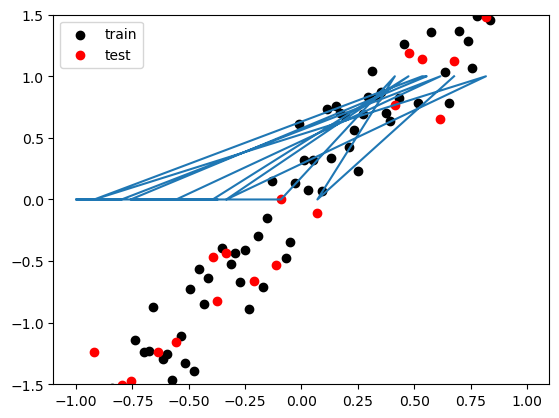

In [44]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='train')
plt.scatter(X_test,y_test,c='red',label='test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

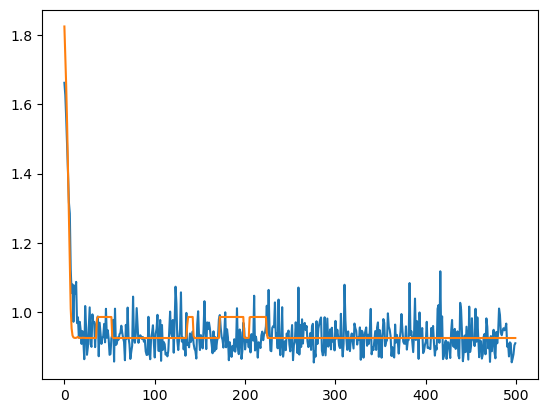

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])